# End-to-End Test

## Import Functions to Test

In [13]:
from raag_midi_gen.tokenizer import encode_target, decode_output

## Import Helper Functions

In [14]:
import random

import muspy

from raag_midi_gen.datasets import midi_files_dataset
from raag_midi_gen.utils.midi_utils import play_muspy_music

In [15]:
test_clip_filename = 'Taraana - Antra 2.0.mid'        # EASY
# test_clip_filename = 'Aeri Aali - Sthaayi 1.1_2.mid'  # HARD

## Get Data Sample

In [16]:
dataset = midi_files_dataset.get_dataset()
midi_filename, original_midi = dataset[test_clip_filename]

Chosen File: Taraana - Antra 2.0.mid
------------------


[<Axes: xlabel='time (beat)', ylabel='\n\npitch'>]

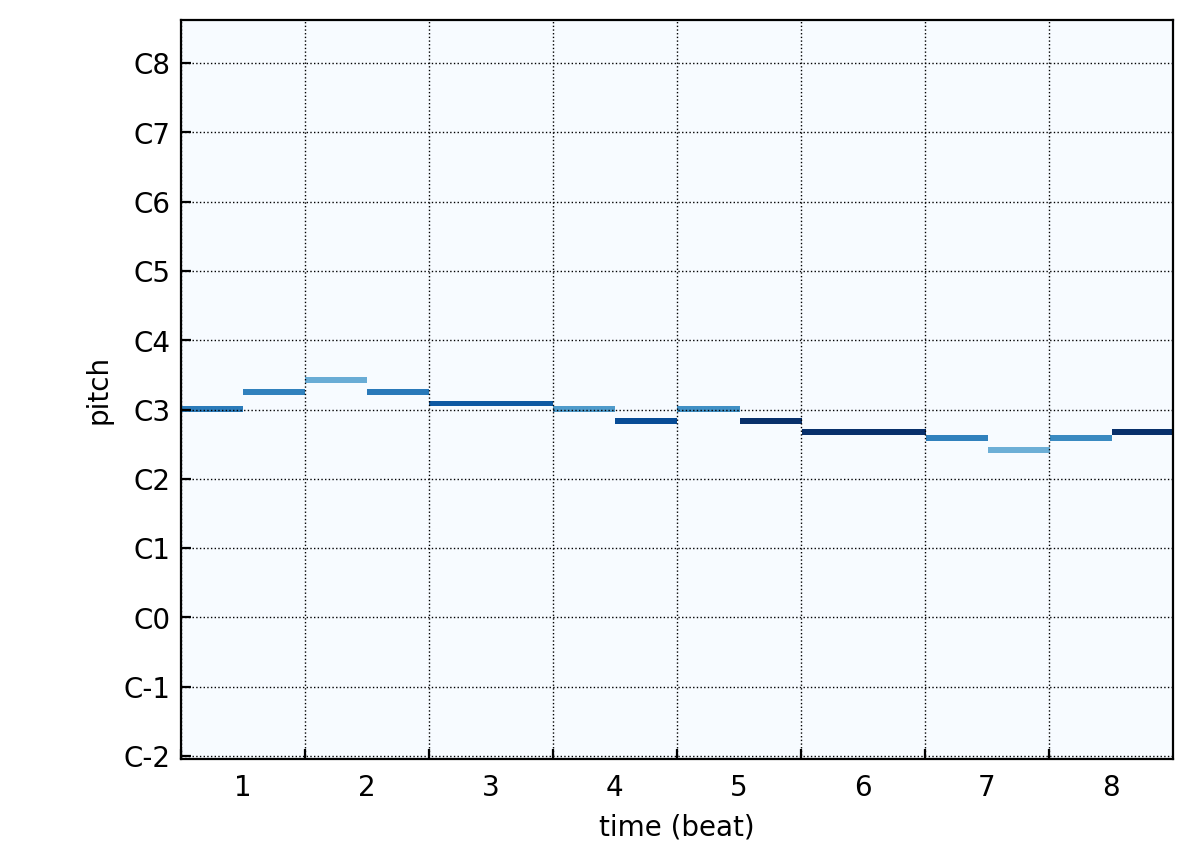

In [17]:
print(f'Chosen File: {midi_filename}')
print('------------------')
muspy.show_pianoroll(original_midi)

## Encode Target

In [18]:
target_encoding = encode_target(original_midi)

pitches = target_encoding['pitch']
octaves = target_encoding['octave']
velocities = target_encoding['velocity']
event_types = target_encoding['event_type']

## Decode

In [19]:
decoded_midi = decode_output(velocities, pitches, octaves, event_types)

## Test Similarity of Decoded and Original

In [20]:
print(f'{midi_filename}: ORIGINAL')
print('------------------')
play_muspy_music(original_midi)

print(f'{midi_filename}: DECODED')
print('------------------')
play_muspy_music(decoded_midi)

Taraana - Antra 2.0.mid: ORIGINAL
------------------
FluidSynth runtime version 2.2.5
Copyright (C) 2000-2022 Peter Hanappe and others.
Distributed under the LGPL license.
SoundFont(R) is a registered trademark of Creative Technology Ltd.

Rendering audio to file 'tmp.wav'..


Taraana - Antra 2.0.mid: DECODED
------------------
FluidSynth runtime version 2.2.5
Copyright (C) 2000-2022 Peter Hanappe and others.
Distributed under the LGPL license.
SoundFont(R) is a registered trademark of Creative Technology Ltd.

Rendering audio to file 'tmp.wav'..


# Inspect Original

In [21]:
original_midi.tracks[0].notes

[Note(time=0, pitch=60, duration=48, velocity=90),
 Note(time=48, pitch=63, duration=48, velocity=87),
 Note(time=96, pitch=65, duration=48, velocity=64),
 Note(time=144, pitch=63, duration=48, velocity=91),
 Note(time=192, pitch=61, duration=96, velocity=107),
 Note(time=288, pitch=60, duration=48, velocity=74),
 Note(time=336, pitch=58, duration=48, velocity=113),
 Note(time=384, pitch=60, duration=48, velocity=80),
 Note(time=432, pitch=58, duration=48, velocity=127),
 Note(time=480, pitch=56, duration=96, velocity=127),
 Note(time=576, pitch=55, duration=48, velocity=87),
 Note(time=624, pitch=53, duration=48, velocity=63),
 Note(time=672, pitch=55, duration=48, velocity=83),
 Note(time=720, pitch=56, duration=48, velocity=127)]

[<Axes: xlabel='time (beat)', ylabel='\n\npitch'>]

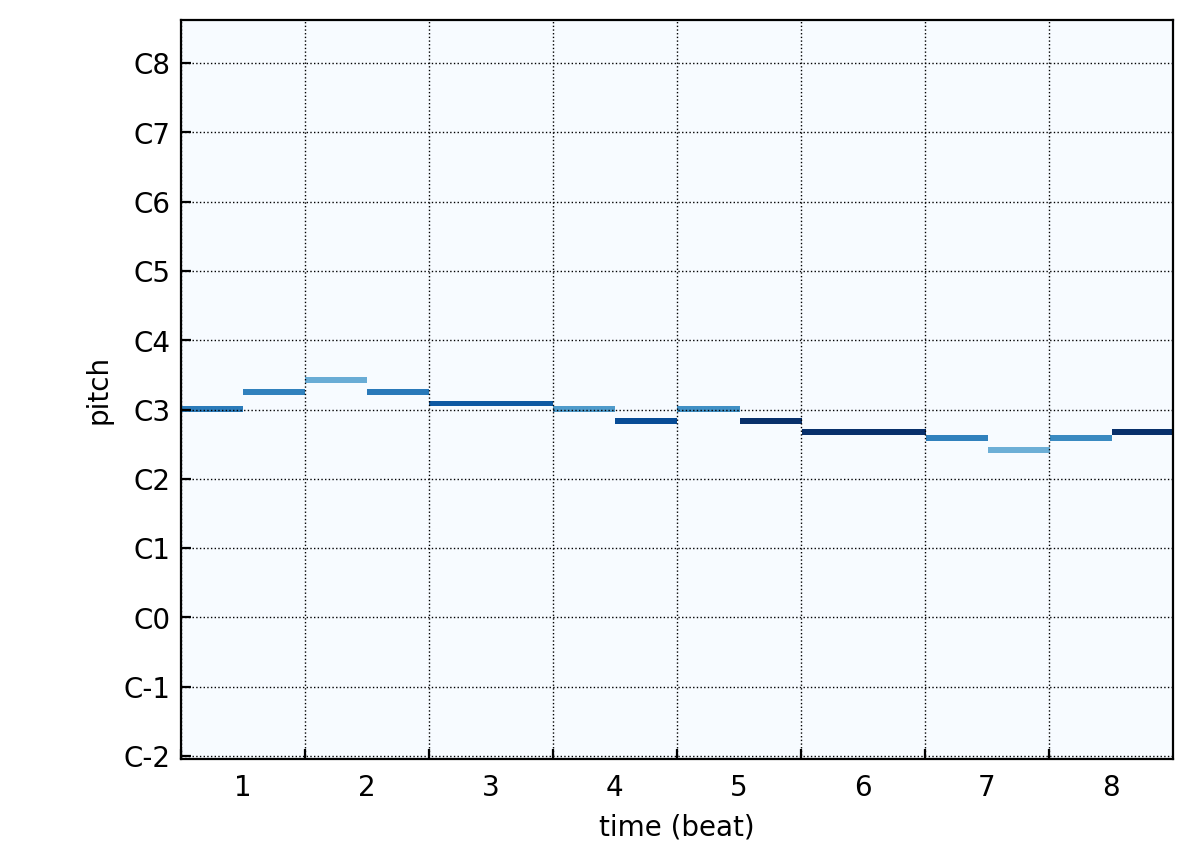

In [22]:
muspy.show_pianoroll(original_midi)

# Inspect Decoded

In [23]:
decoded_midi.tracks[0].notes

[Note(time=0, pitch=60, duration=48, velocity=90),
 Note(time=49, pitch=63, duration=47, velocity=87),
 Note(time=97, pitch=65, duration=47, velocity=64),
 Note(time=145, pitch=63, duration=47, velocity=91),
 Note(time=193, pitch=61, duration=95, velocity=107),
 Note(time=289, pitch=60, duration=47, velocity=74),
 Note(time=337, pitch=58, duration=47, velocity=113),
 Note(time=385, pitch=60, duration=47, velocity=80),
 Note(time=433, pitch=58, duration=47, velocity=127),
 Note(time=481, pitch=56, duration=95, velocity=127),
 Note(time=577, pitch=55, duration=47, velocity=87),
 Note(time=625, pitch=53, duration=47, velocity=63),
 Note(time=673, pitch=55, duration=47, velocity=83),
 Note(time=721, pitch=56, duration=47, velocity=127)]

[<Axes: xlabel='time (beat)', ylabel='\n\npitch'>]

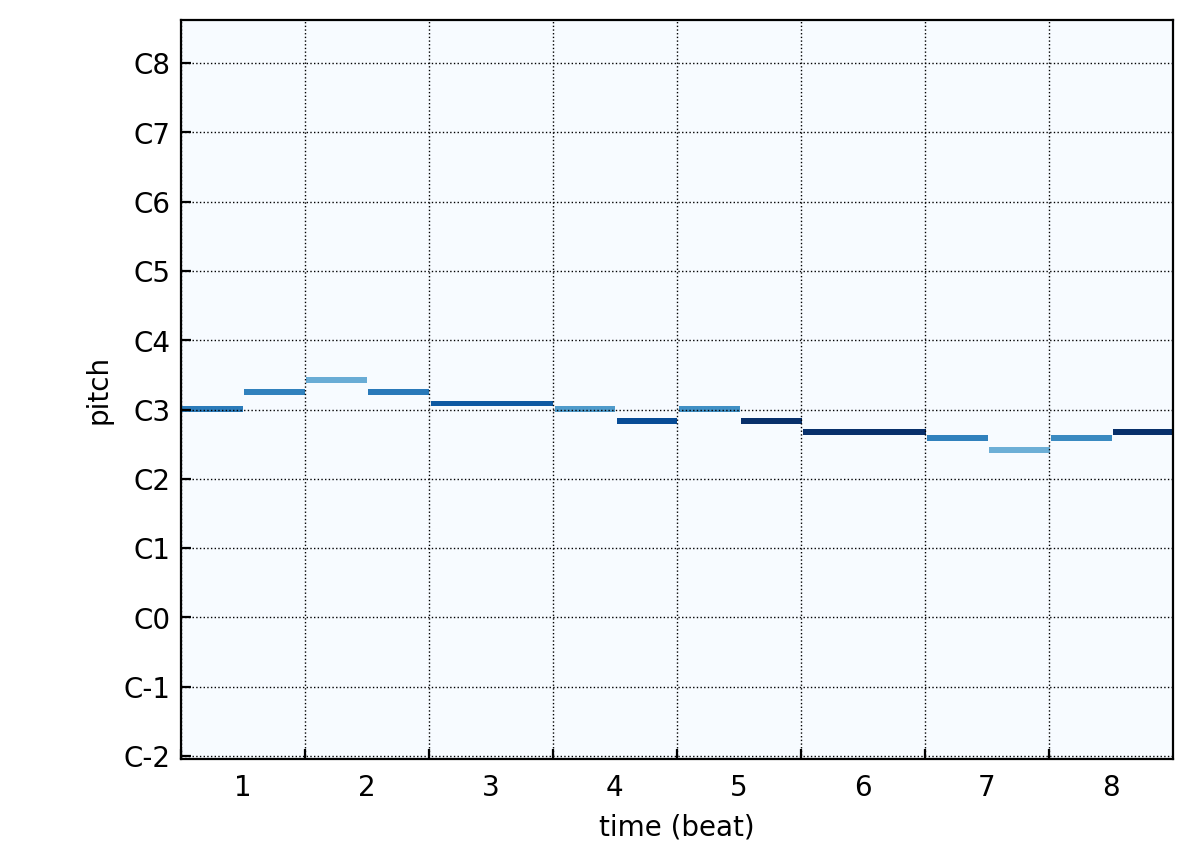

In [24]:
muspy.show_pianoroll(decoded_midi)